# Portfolio Optimization

**Markowitz mean-variance optimization with Moreau** — four interfaces to the same problem, from CVXPY one-liners to batched GPU solves with differentiability and warm starting.

This notebook demonstrates:
- **CVXPY interface** — formulate in CVXPY, solve with `solver=cp.MOREAU`
- **`moreau.Solver`** — direct access to the conic solver
- **`moreau.CompiledSolver`** — batched GPU solve sweeping 200 risk-aversion parameters at once
- **`moreau.torch.Solver`** — differentiable optimization with automatic Jacobians and warm starting


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import time

import torch
import cvxpy as cp
import moreau
from moreau.torch import Solver as TorchSolver
from utils.style import set_moreau_style, MOREAU_COLORS, moreau_gradient, annotate_speedup
from utils.sparse import sparse_to_csr, build_solver

set_moreau_style()
np.random.seed(42)

## Generate Synthetic Asset Returns

We use a factor model to create a realistic covariance matrix: $\Sigma = F F^\top + D$ where $F$ is the factor loading matrix and $D$ captures asset-specific risk.


In [2]:
n_assets = 200
n_factors = 10

# Factor loadings and specific risk
F = np.random.randn(n_assets, n_factors) * 0.1
D = np.diag(np.random.uniform(0.01, 0.05, n_assets))

# Covariance: Sigma = F @ F' + D
Sigma = F @ F.T + D

# Expected returns (spread around 8% annual)
mu = np.random.uniform(0.02, 0.15, n_assets)

print(f"Assets: {n_assets}")
print(f"Factors: {n_factors}")
print(f"Expected returns: {mu.min():.1%} to {mu.max():.1%}")
print(f"Volatilities: {np.sqrt(np.diag(Sigma)).min():.1%} to {np.sqrt(np.diag(Sigma)).max():.1%}")

Assets: 200
Factors: 10
Expected returns: 2.0% to 14.9%
Volatilities: 20.4% to 54.7%


## CVXPY Interface

The simplest way to use Moreau: formulate your problem in CVXPY and pass `solver=cp.MOREAU`.

The Markowitz portfolio optimization problem:

$$\min_w \; \gamma \, w^\top \Sigma \, w - \mu^\top w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \; w \geq 0$$


In [3]:
gamma = 1.0  # risk aversion

w_cp = cp.Variable(n_assets)
objective = cp.Minimize(gamma * cp.quad_form(w_cp, Sigma) - mu @ w_cp)
constraints = [cp.sum(w_cp) == 1, w_cp >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.MOREAU)

print(f"Status: {prob.status}")
print(f"Expected return: {(mu @ w_cp.value):.2%}")
print(f"Portfolio risk:  {np.sqrt(w_cp.value @ Sigma @ w_cp.value):.2%}")

Status: optimal
Expected return: 14.57%
Portfolio risk:  5.01%


## Single Solve with `moreau.Solver`

The Markowitz problem:

$$\min_w \; \gamma \, w^\top \Sigma \, w - \mu^\top w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1, \; w \geq 0$$

In Moreau's standard form: $\min \frac{1}{2} x^\top P x + q^\top x$ s.t. $Ax + s = b$, $s \in \mathcal{K}$


In [4]:
gamma = 1.0  # risk aversion

# Quadratic cost: P = 2*gamma*Sigma (Moreau uses 1/2 x'Px)
P = sparse.csr_array(2 * gamma * Sigma)
q = -mu

# Constraints: [1'w = 1 (equality), w >= 0 (nonneg via -Iw + s = 0, s >= 0)]
A_eq = np.ones((1, n_assets))     # sum to 1
A_ineq = -np.eye(n_assets)        # -w + s = 0 => w = s >= 0
A = sparse.csr_array(np.vstack([A_eq, A_ineq]))
b = np.zeros(1 + n_assets)
b[0] = 1.0  # sum = 1

cones = moreau.Cones(num_zero_cones=1, num_nonneg_cones=n_assets)

settings_single = moreau.Settings(
    device="cuda",
    ipm_settings=moreau.IPMSettings(direct_solve_method="cudss"),
)
solver = moreau.Solver(P, q, A, b, cones=cones, settings=settings_single)
sol = solver.solve()

w_star = sol.x
print(f"Status: {solver.info.status.name}")
print(f"Expected return: {mu @ w_star:.2%}")
print(f"Portfolio risk:  {np.sqrt(w_star @ Sigma @ w_star):.2%}")
print(f"Iterations:     {solver.info.iterations}")

Status: Solved
Expected return: 14.57%
Portfolio risk:  5.01%
Iterations:     8


## Batched Efficient Frontier with `CompiledSolver`

Now the magic: sweep 200 values of $\gamma$ in a **single batched call**. All problems share the same constraint structure — only `P` (which encodes $\gamma \Sigma$) changes.


In [5]:
# --- Sweep 200 gamma values ---
n_gammas = 200
gammas = np.logspace(-2, 2, n_gammas)

# Build CompiledSolver on CUDA
P_base = sparse.csr_array(2 * Sigma)  # gamma=1 structure
P_ro, P_ci, P_base_vals = sparse_to_csr(P_base)
A_ro, A_ci, A_vals = sparse_to_csr(A)

settings = moreau.Settings(
    batch_size=n_gammas,
    device="cuda",
    ipm_settings=moreau.IPMSettings(direct_solve_method="cudss"),
)
compiled = moreau.CompiledSolver(
    n=n_assets, m=1 + n_assets,
    P_row_offsets=P_ro, P_col_indices=P_ci,
    A_row_offsets=A_ro, A_col_indices=A_ci,
    cones=cones, settings=settings,
)

# Each gamma scales P: P_gamma = 2 * gamma * Sigma
P_vals_batch = np.outer(gammas, P_base_vals)  # (n_gammas, nnz_P)
A_vals_batch = np.tile(A_vals, (n_gammas, 1))
compiled.setup(P_vals_batch, A_vals_batch)

# q = -mu for all problems, b is the same for all
qs = np.tile(-mu, (n_gammas, 1))
bs = np.tile(b, (n_gammas, 1))

batch_sol = compiled.solve(qs=qs, bs=bs)

# Extract returns and risks
weights = batch_sol.x  # (n_gammas, n_assets)
returns = weights @ mu
risks = np.array([np.sqrt(w @ Sigma @ w) for w in weights])

print(f"Solved {n_gammas} problems in a single batched call")
print(f"All solved: {all(s == moreau.SolverStatus.Solved for s in compiled.info.status)}")

Solved 200 problems in a single batched call
All solved: False


## Efficient Frontier Visualization


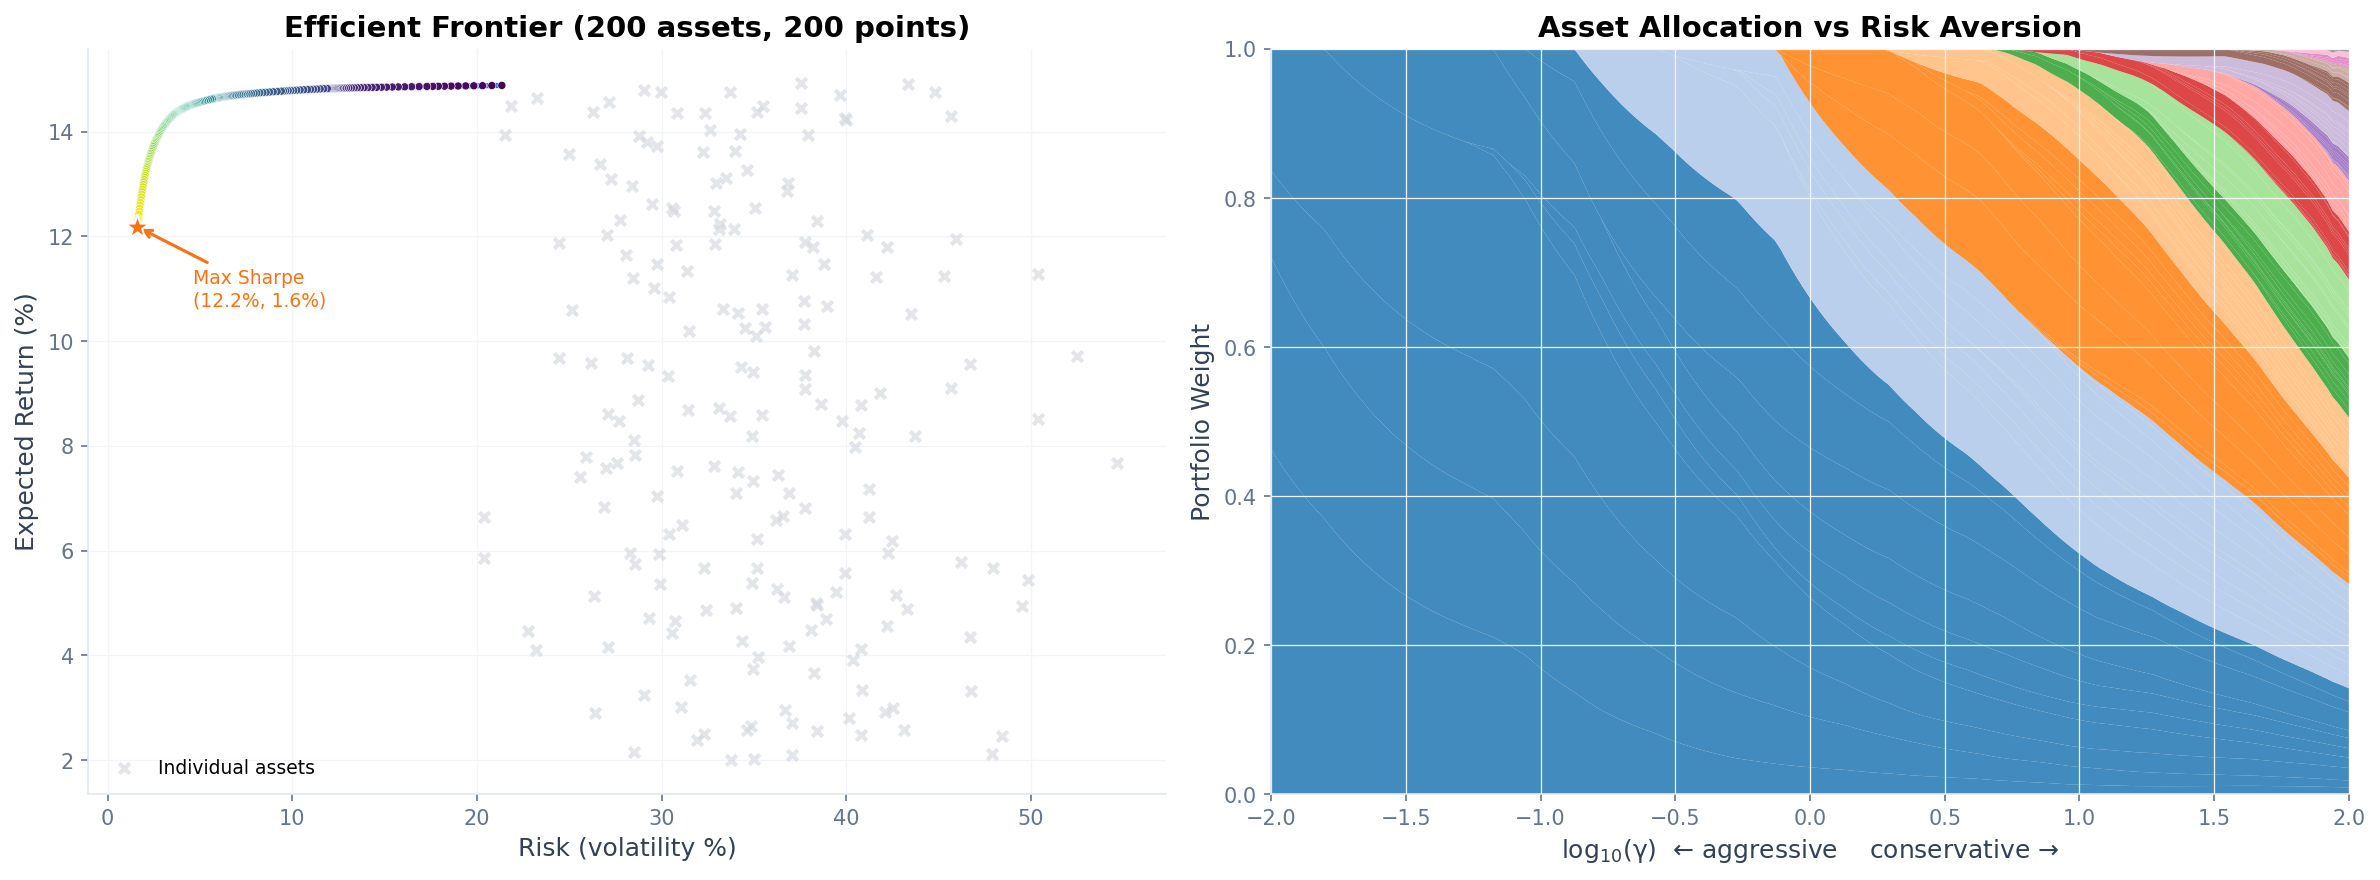

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Efficient Frontier ---
ax = axes[0]
colors = moreau_gradient(n_gammas)
for i in range(n_gammas - 1):
    ax.plot(risks[i:i+2] * 100, returns[i:i+2] * 100, '-', color=colors[i], linewidth=2.5)
ax.scatter(risks * 100, returns * 100, c=np.log10(gammas), cmap='viridis',
           s=15, zorder=5, edgecolors='white', linewidth=0.3)

# Mark tangency portfolio (max Sharpe)
sharpe = returns / risks
best = np.argmax(sharpe)
ax.scatter(risks[best]*100, returns[best]*100, s=150, marker='*',
           color=MOREAU_COLORS['accent'], zorder=10, edgecolors='white', linewidth=1)
ax.annotate(f'Max Sharpe\n({returns[best]:.1%}, {risks[best]:.1%})',
            xy=(risks[best]*100, returns[best]*100),
            xytext=(risks[best]*100 + 3, returns[best]*100 - 1.5),
            fontsize=9, color=MOREAU_COLORS['accent'],
            arrowprops=dict(arrowstyle='->', color=MOREAU_COLORS['accent'], lw=1.5))

# Individual assets
asset_vols = np.sqrt(np.diag(Sigma)) * 100
ax.scatter(asset_vols, mu * 100, c=MOREAU_COLORS['neutral_light'],
           s=25, marker='x', zorder=4, alpha=0.6, label='Individual assets')

ax.set_xlabel('Risk (volatility %)')
ax.set_ylabel('Expected Return (%)')
ax.set_title(f'Efficient Frontier ({n_assets} assets, {n_gammas} points)')
ax.legend(fontsize=9)

# --- Panel 2: Stacked Area Chart ---
ax = axes[1]
asset_order = np.argsort(mu)[::-1]
sorted_weights = weights[:, asset_order]

cmap = plt.get_cmap('tab20')
area_colors = [cmap(i / n_assets) for i in range(n_assets)]

ax.stackplot(np.log10(gammas), sorted_weights.T, colors=area_colors, alpha=0.85)
ax.set_xlabel('log$_{10}$(\u03b3)  \u2190 aggressive    conservative \u2192')
ax.set_ylabel('Portfolio Weight')
ax.set_title('Asset Allocation vs Risk Aversion')
ax.set_xlim(np.log10(gammas[0]), np.log10(gammas[-1]))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../assets/portfolio.png', bbox_inches='tight', facecolor='white')
plt.show()

## Differentiable Optimization: Jacobian of Weights w.r.t. Returns

How sensitive is the optimal portfolio to changes in expected returns? Using `moreau.torch.Solver`, we can compute the full Jacobian $J_{ij} = \partial w^*_i / \partial \mu_j$ via automatic differentiation.

This is the key building block for:
- **End-to-end learning**: backpropagating through the optimization layer in a neural network
- **Sensitivity analysis**: understanding which return estimates most affect the allocation
- **Robust optimization**: bounding worst-case portfolio changes under return uncertainty


In [ ]:
# --- Build torch solver for a single Markowitz QP ---
gamma_fixed = 1.0
n = n_assets
m = 1 + n_assets

P_sp = sparse.csr_array(2 * gamma_fixed * Sigma)
P_sp.sort_indices()
P_ro_t = torch.tensor(P_sp.indptr, dtype=torch.int64)
P_ci_t = torch.tensor(P_sp.indices, dtype=torch.int64)
P_val_t = torch.tensor(P_sp.data, dtype=torch.float64)

A_sp = sparse.csr_array(np.vstack([np.ones((1, n)), -np.eye(n)]))
A_sp.sort_indices()
A_ro_t = torch.tensor(A_sp.indptr, dtype=torch.int64)
A_ci_t = torch.tensor(A_sp.indices, dtype=torch.int64)
A_val_t = torch.tensor(A_sp.data, dtype=torch.float64)

cones_t = moreau.Cones(num_zero_cones=1, num_nonneg_cones=n)

torch_solver = TorchSolver(
    n=n, m=m,
    P_row_offsets=P_ro_t,
    P_col_indices=P_ci_t,
    A_row_offsets=A_ro_t,
    A_col_indices=A_ci_t,
    cones=cones_t,
    settings=moreau.Settings(
        device="cpu",
        solver="active_set",
    ),
)

# --- Solve with differentiable mu ---
mu_t = torch.tensor(mu, dtype=torch.float64, requires_grad=True)
b_t = torch.tensor(b, dtype=torch.float64)
q_t = -mu_t  # linear cost

sol = torch_solver.solve(P_val_t, A_val_t, q_t, b_t)
w_star = sol.x

print(f"Status: {torch_solver.info.status.name}")
print(f"Expected return: {(mu_t.detach() @ w_star.detach()).item():.2%}")
print(f"Iterations: {int(torch_solver.info.iterations)}")

# --- Compute full Jacobian: d(w*)/d(mu) ---
jacobian = torch.zeros(n, n, dtype=torch.float64)
for i in range(n):
    if mu_t.grad is not None:
        mu_t.grad.zero_()
    sol.x[i].backward(retain_graph=True)
    jacobian[i] = mu_t.grad.clone()

J = jacobian.detach().numpy()
print(f"\nJacobian shape: {J.shape}")
print(f"Jacobian norm: {np.linalg.norm(J):.4f}")
print(f"Max |J_ij|: {np.abs(J).max():.4f}")

# --- Plot Jacobian as a heatmap ---
fig, ax = plt.subplots(figsize=(10, 8))

# Diverging colormap: blue (negative) -> white (zero) -> orange (positive)
jac_cmap = mcolors.LinearSegmentedColormap.from_list(
    'moreau_diverging',
    [MOREAU_COLORS['primary'], '#FFFFFF', MOREAU_COLORS['accent']],
    N=256,
)

vmax = np.abs(J).max()
sns.heatmap(
    J, ax=ax, cmap=jac_cmap, center=0, vmin=-vmax, vmax=vmax,
    square=True, linewidths=0,
    cbar_kws={'label': '$\\partial w^*_i / \\partial \\mu_j$', 'shrink': 0.8},
    xticklabels=5, yticklabels=5,
)
ax.set_xlabel('Return dimension $j$ ($\\mu_j$)')
ax.set_ylabel('Weight dimension $i$ ($w^*_i$)')
ax.set_title(f'Jacobian $\\partial w^* / \\partial \\mu$ at $\\gamma = {gamma_fixed}$', pad=15)

plt.tight_layout()
plt.show()

# Interpretation
diag = np.diag(J)
print(f"\nDiagonal (self-sensitivity): mean = {diag.mean():.4f}, range = [{diag.min():.4f}, {diag.max():.4f}]")
print(f"Off-diagonal (cross-sensitivity): mean |off-diag| = {np.abs(J - np.diag(diag)).mean():.4f}")
print(f"\nA positive diagonal entry J_ii means increasing mu_i raises w*_i (as expected).")
print(f"Negative off-diagonal entries J_ij mean increasing mu_j decreases w*_i (substitution effect).")

## Rolling-Window Rebalancing with Warm Starting

In practice, portfolios are rebalanced periodically as return estimates and covariance matrices evolve. Each rebalancing solves a slightly different QP.

**Warm starting** passes the previous solution as an initial point for the next solve, allowing the interior-point method to converge in fewer iterations. We simulate 200 rebalancing periods with slowly drifting $\mu$ and $\Sigma$, comparing cold starts vs warm starts.


In [ ]:
n_periods = 200
gamma_rebal = 1.0

# --- Storage ---
weights_warm = np.zeros((n_periods, n_assets))
weights_cold = np.zeros((n_periods, n_assets))
iters_warm = np.zeros(n_periods, dtype=int)
iters_cold = np.zeros(n_periods, dtype=int)

# --- Precompute drifting parameters ---
np.random.seed(123)
mu_base = mu.copy()
F_base = F.copy()
D_base = D.copy()

# Small random walk for mu and factors at each period
mu_drift = np.cumsum(np.random.randn(n_periods, n_assets) * 0.002, axis=0)
F_drift = np.cumsum(np.random.randn(n_periods, n_assets, n_factors) * 0.005, axis=0)

# --- Build torch solver (single, reusable structure) ---
# The constraint structure is the same every period; only P, q change.
P_sp = sparse.csr_array(2 * gamma_rebal * Sigma)
P_sp.sort_indices()
A_sp = sparse.csr_array(np.vstack([np.ones((1, n_assets)), -np.eye(n_assets)]))
A_sp.sort_indices()

P_ro_w = torch.tensor(P_sp.indptr, dtype=torch.int64)
P_ci_w = torch.tensor(P_sp.indices, dtype=torch.int64)
A_ro_w = torch.tensor(A_sp.indptr, dtype=torch.int64)
A_ci_w = torch.tensor(A_sp.indices, dtype=torch.int64)
A_val_w = torch.tensor(A_sp.data, dtype=torch.float64)

cones_w = moreau.Cones(num_zero_cones=1, num_nonneg_cones=n_assets)
b_w = torch.tensor(b, dtype=torch.float64)

torch_settings = moreau.Settings(
    device="cpu",
    solver="active_set",
)

# Warm solver
solver_warm = TorchSolver(
    n=n_assets, m=1 + n_assets,
    P_row_offsets=P_ro_w, P_col_indices=P_ci_w,
    A_row_offsets=A_ro_w, A_col_indices=A_ci_w,
    cones=cones_w,
    settings=torch_settings,
)

# Cold solver (identical structure, no warm start)
solver_cold = TorchSolver(
    n=n_assets, m=1 + n_assets,
    P_row_offsets=P_ro_w, P_col_indices=P_ci_w,
    A_row_offsets=A_ro_w, A_col_indices=A_ci_w,
    cones=cones_w,
    settings=torch_settings,
)

warm_start_obj = None

for t in range(n_periods):
    # Drifting parameters
    mu_t_np = np.clip(mu_base + mu_drift[t], 0.001, 0.30)
    F_t = F_base + F_drift[t]
    Sigma_t = F_t @ F_t.T + D_base

    # Build P for this period
    P_t_sp = sparse.csr_array(2 * gamma_rebal * Sigma_t)
    P_t_sp.sort_indices()
    P_val_w_t = torch.tensor(P_t_sp.data, dtype=torch.float64)

    q_t_np = -mu_t_np
    q_t_w = torch.tensor(q_t_np, dtype=torch.float64)

    # --- Warm start solve ---
    sol_warm = solver_warm.solve(P_val_w_t, A_val_w, q_t_w, b_w, warm_start=warm_start_obj)
    weights_warm[t] = sol_warm.x.detach().numpy()
    iters_warm[t] = int(solver_warm.info.iterations)

    # Update warm start for next period
    warm_start_obj = sol_warm.to_warm_start()

    # --- Cold start solve (no warm start) ---
    sol_cold = solver_cold.solve(P_val_w_t, A_val_w, q_t_w, b_w)
    weights_cold[t] = sol_cold.x.detach().numpy()
    iters_cold[t] = int(solver_cold.info.iterations)

print(f"Rolling rebalancing over {n_periods} periods")
print(f"Warm start: mean {iters_warm.mean():.1f} iters, total {iters_warm.sum()} iters")
print(f"Cold start: mean {iters_cold.mean():.1f} iters, total {iters_cold.sum()} iters")
print(f"Warm start reduction: {(1 - iters_warm.sum() / iters_cold.sum()) * 100:.1f}%")

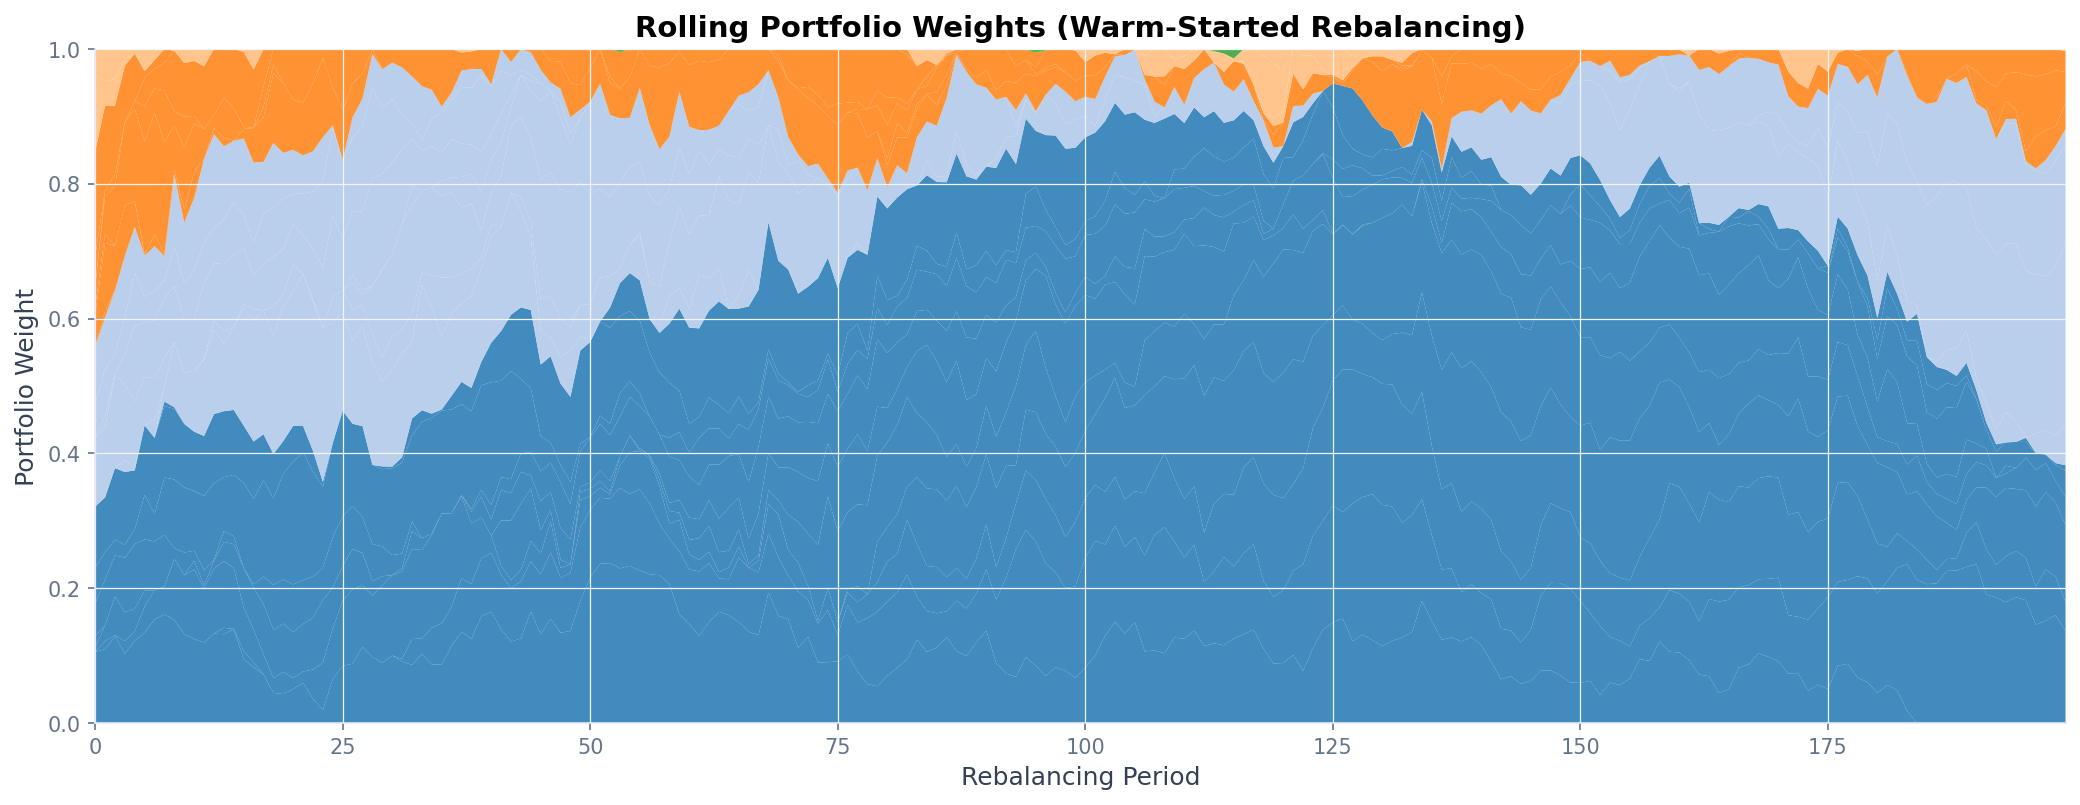

In [9]:
# --- Stacked area chart of rolling portfolio weights ---
fig, ax = plt.subplots(figsize=(14, 5.5))

# Sort assets by average weight for cleaner visual stacking
avg_weight = weights_warm.mean(axis=0)
asset_order = np.argsort(avg_weight)[::-1]
sorted_w = weights_warm[:, asset_order]

# Color palette
cmap_area = plt.get_cmap('tab20')
area_colors = [cmap_area(i / n_assets) for i in range(n_assets)]

ax.stackplot(range(n_periods), sorted_w.T, colors=area_colors, alpha=0.85)
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('Portfolio Weight')
ax.set_title('Rolling Portfolio Weights (Warm-Started Rebalancing)')
ax.set_xlim(0, n_periods - 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Warm Start Iteration Comparison

The chart below shows how warm starting reduces the number of interior-point iterations at each rebalancing period. Since consecutive problems are similar, the warm-started solver typically converges much faster.


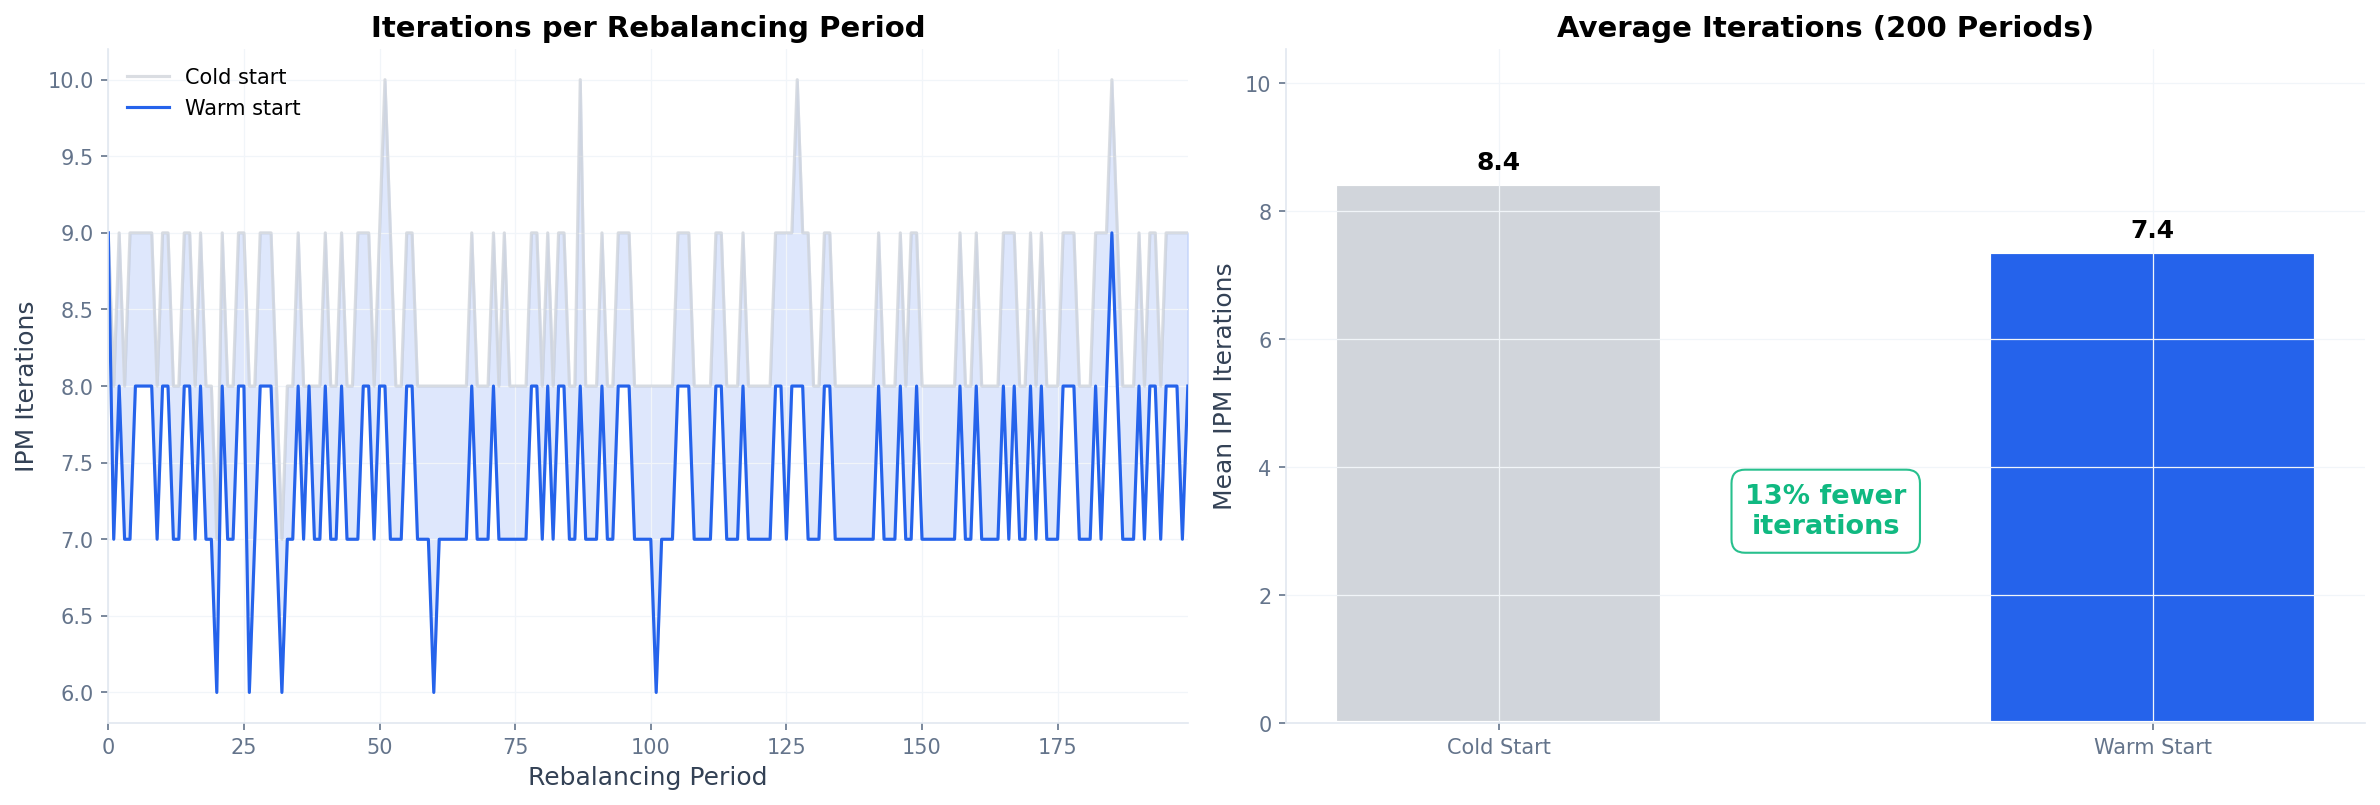

Total iterations -- Cold: 1686, Warm: 1472
Iteration reduction: 12.7%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# --- Panel 1: Iteration trace over time ---
ax = axes[0]
ax.plot(range(n_periods), iters_cold, color=MOREAU_COLORS['neutral_light'],
        linewidth=1.5, alpha=0.8, label='Cold start')
ax.plot(range(n_periods), iters_warm, color=MOREAU_COLORS['primary'],
        linewidth=1.5, label='Warm start')
ax.fill_between(range(n_periods), iters_warm, iters_cold,
                alpha=0.15, color=MOREAU_COLORS['primary'])
ax.set_xlabel('Rebalancing Period')
ax.set_ylabel('IPM Iterations')
ax.set_title('Iterations per Rebalancing Period')
ax.legend(fontsize=10)
ax.set_xlim(0, n_periods - 1)

# --- Panel 2: Summary bar chart ---
ax = axes[1]
means = [iters_cold.mean(), iters_warm.mean()]
bars = ax.bar(
    ['Cold Start', 'Warm Start'],
    means,
    color=[MOREAU_COLORS['neutral_light'], MOREAU_COLORS['primary']],
    width=0.5,
    edgecolor='white',
    linewidth=2,
)

# Add value labels on top of bars
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Speedup annotation — centered between bars, below the value labels
if iters_warm.mean() > 0:
    reduction = (1 - iters_warm.mean() / iters_cold.mean()) * 100
    mid_x = (bars[0].get_x() + bars[0].get_width() + bars[1].get_x()) / 2
    mid_y = min(means) * 0.45
    ax.text(
        mid_x, mid_y,
        f'{reduction:.0f}% fewer\niterations',
        ha='center', va='center', fontsize=13, fontweight='bold',
        color=MOREAU_COLORS['success'],
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor=MOREAU_COLORS['success'], alpha=0.9),
    )

ax.set_ylabel('Mean IPM Iterations')
ax.set_title(f'Average Iterations ({n_periods} Periods)')
ax.set_ylim(0, max(means) * 1.25)

plt.tight_layout()
plt.show()

print(f"Total iterations -- Cold: {iters_cold.sum()}, Warm: {iters_warm.sum()}")
print(f"Iteration reduction: {(1 - iters_warm.sum() / iters_cold.sum()) * 100:.1f}%")

---

**Key takeaways:**

- **CVXPY interface** — formulate naturally in CVXPY, solve with `solver=cp.MOREAU` as a drop-in backend
- **`moreau.Solver`** — direct conic solver for full control over problem structure
- **Batched GPU solve** — trace the full efficient frontier in a single `CompiledSolver` call, sweeping 200 risk-aversion parameters simultaneously
- **Differentiable optimization** — `moreau.torch.Solver` gives exact gradients through the QP solution, enabling sensitivity analysis and end-to-end learning
- **Warm starting** — reuse the previous solution as an initial point, reducing IPM iterations for slowly-changing problems like rolling rebalancing
- These capabilities — multiple interfaces, batching, differentiability, and warm starting — compose naturally in Moreau's API
